<img src="https://devra.ai/analyst/notebook/1804/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">    <div style="font-size:150%; color:#FEE100"><b>IMDB Top 250 Movies Analysis and Predictor</b></div>    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>Welcome to this exploration of the IMDB Top 250 Movies dataset. The dataset may be small in size but it packs a punch with its ranking, release year, rating and runtime. If you find this notebook useful, please do upvote it.

## Table of Contents

- [Introduction](#Introduction)
- [Data Loading and Preprocessing](#Data-Loading-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictor Model: Predicting Movie Rating](#Predictor-Model:-Predicting-Movie-Rating)
- [Conclusion](#Conclusion)

## Introduction

In this notebook we dive into the analysis of the IMDB Top 250 Movies. While ranking and general popularity provide insights, it becomes interesting to see how numeric features such as release year, rating and runtime interact. We will also attempt to create a predictor for movie ratings using available features. Let's begin our journey into data, complete with a smattering of visualizations and analytics.

In [1]:
# Importing essential libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # use Agg backend as required
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # in case only plt is imported

import seaborn as sns

# Enable inline plotting for Kaggle notebooks
%matplotlib inline

# Setting a style for seaborn plots
sns.set(style='whitegrid')

## Data Loading and Preprocessing

We now load the data from the `imdb_top_250.csv` file. The dataset includes features such as Rank, Title, Year, Rating and Runtime. Note the `Year` column represents a date-like value (the release year) and is handled appropriately.

In [2]:
# Loading the dataset
df = pd.read_csv('/kaggle/input/imdb-top-250-movies/imdb_top_250.csv', encoding='utf-8')
print('Data loaded successfully.')

# Quick peek at the dataframe
df.head()

Data loaded successfully.


,Rank,Title,Year,Rating,Runtime
0,1,The Shawshank Redemption,1994,9.3,142
1,2,The Godfather,1972,9.2,175
2,3,The Dark Knight,2008,9.0,152
3,4,The Godfather Part II,1974,9.0,202
4,5,12 Angry Men,1957,9.0,96


In [3]:
# Data Cleaning and Preprocessing

# Checking for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# In this dataset, missing values are not expected, but this is a good check.

# Convert 'Year' to a date format if needed - here it represents the movie release year
df['Year'] = pd.to_datetime(df['Year'], format='%Y', errors='coerce')

# Confirming the conversion
print('Data type of Year column after conversion: ', df['Year'].dtype)

# It's always useful to check for duplicate entries
print('Number of duplicate rows: ', df.duplicated().sum())

Missing values in each column:
Rank       0
Title      0
Year       0
Rating     0
Runtime    0
dtype: int64
Data type of Year column after conversion:  datetime64[ns]
Number of duplicate rows:  0


## Exploratory Data Analysis

We now perform exploratory analysis on the dataset with multiple plots to see patterns and relationships between the variables.

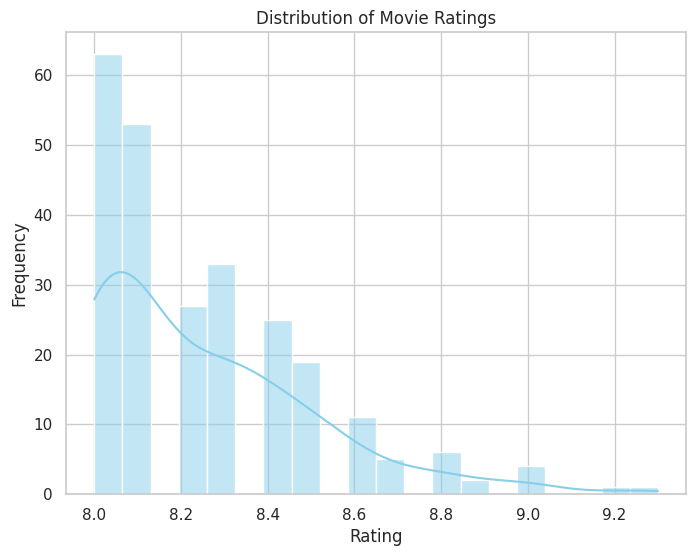

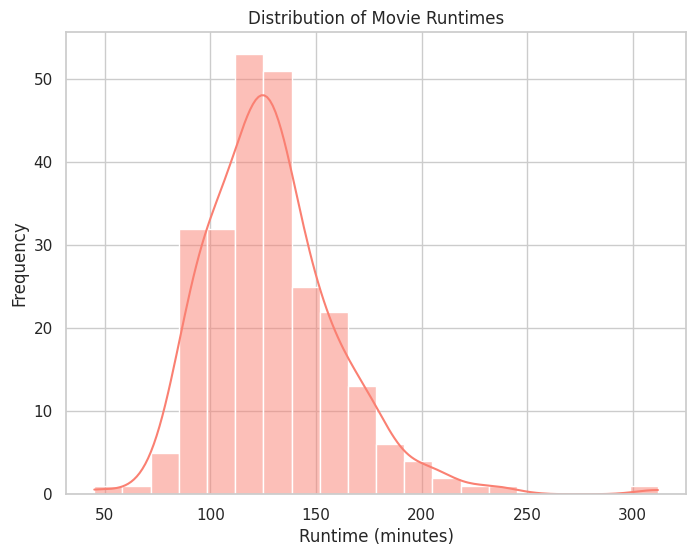

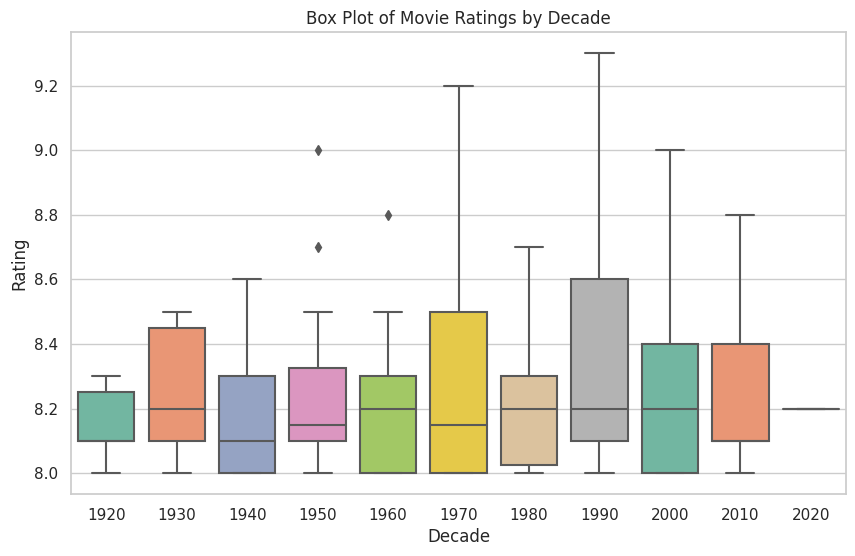

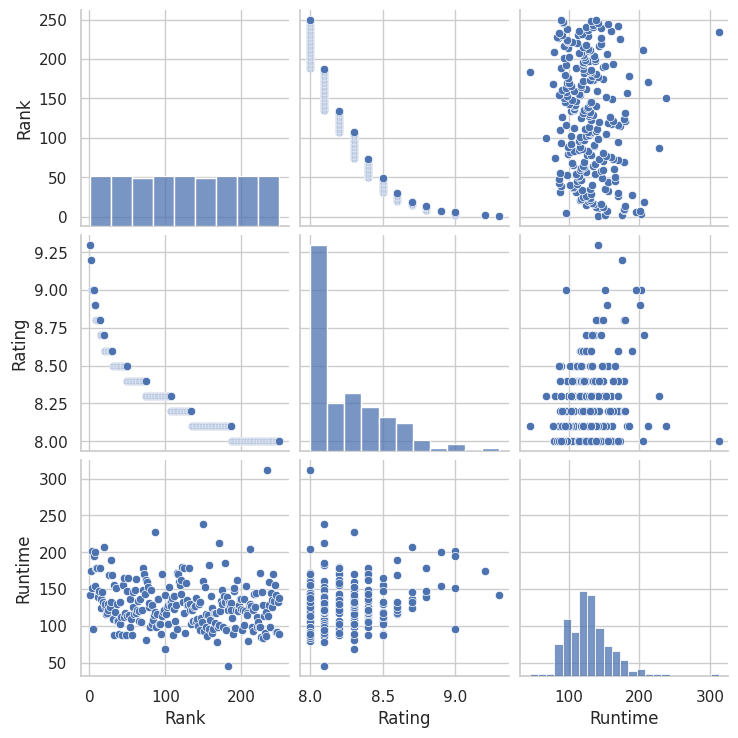

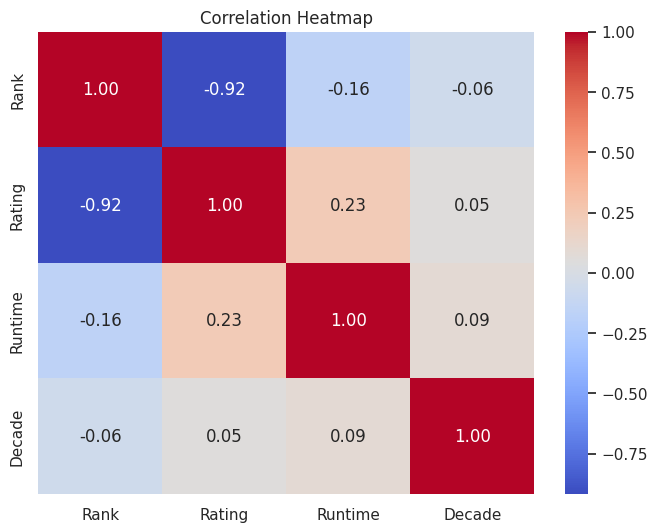

In [4]:
# Plot 1: Distribution of Movie Ratings
plt.figure(figsize=(8, 6))
sns.histplot(df['Rating'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Plot 2: Distribution of Movie Runtimes
plt.figure(figsize=(8, 6))
sns.histplot(df['Runtime'], kde=True, bins=20, color='salmon')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.show()

# Plot 3: Box Plot for Ratings by Decade
# Create a new column to represent the decade
df['Decade'] = (df['Year'].dt.year // 10) * 10

plt.figure(figsize=(10, 6))
sns.boxplot(x='Decade', y='Rating', data=df, palette='Set2')
plt.title('Box Plot of Movie Ratings by Decade')
plt.xlabel('Decade')
plt.ylabel('Rating')
plt.show()

# Plot 4: Pair Plot for numeric variables
# We limit to numeric columns: Rank, Rating, and Runtime (Year is date now)
sns.pairplot(df[['Rank', 'Rating', 'Runtime']])
plt.show()

# Plot 5: Correlation Heatmap for numeric variables
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print('Not enough numeric columns for a heatmap (requires 4 or more).')

## Predictor Model: Predicting Movie Rating

While it may seem unconventional to predict ratings using the same ratings dataset, we can attempt a simple regression model using features such as the release year (extracted as a numerical feature) and runtime. This can help demonstrate the process of building a regression model and evaluating its performance. Note that the data size is limited so the model is more demonstrative than definitive.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Preparing the data for prediction
# Feature Engineering: Extract the release year as an integer from the datetime column
df['Release_Year'] = df['Year'].dt.year

# Our features will be 'Release_Year' and 'Runtime'
features = ['Release_Year', 'Runtime']
target = 'Rating'

X = df[features]
y = df[target]

# Splitting the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R^2 Score:', r2)

# For those who may encounter issues with shapes during train_test_split or feature extraction, ensure you're correctly converting datetime types.

Mean Squared Error: 0.06257180048208073
R^2 Score: 0.06909366100213199


## Conclusion

This notebook explored the IMDB Top 250 Movies dataset through data cleaning, visualization and a simple linear regression model to predict movie ratings. Although the predictor is demonstrative, the analysis reflects a multi-step approach from data introspection to model evaluation. Future analyses might include additional features, more advanced models, or even text analysis on plot summaries if available. Your suggestions and upvotes are appreciated if you found this helpful.